# Camada Analítica (Business Answers)

Nesta camada (Gold Layer), utilizamos a tabela limpa e padronizada proveniente da **Camada Silver** (`vw_silver_nyc_taxi_consumption`) para responder às perguntas de negócio do case. 

Para garantir a acurácia dos dados financeiros e de operação, foram aplicadas as seguintes premissas analíticas:
* Valores totais (`total_amount`) negativos ou zerados foram removidos das agregações financeiras para não distorcer a média com estornos de cartão.
* Contagens de passageiros inválidas foram removidas da média horária.
* Uma coluna de volume (`total_trips`) foi adicionada lado a lado com a média para dar visibilidade da significância da amostra.

In [0]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "pandas", "-q"])

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import io
from IPython.display import display, Image as IPImage



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Pergunta 1
**Qual a média do `total_amount` por mês (apenas para a frota Yellow)?**

+------------+----------------+-----------+
|pickup_month|avg_total_amount|total_trips|
+------------+----------------+-----------+
|           1|           27.46|    2917184|
|           2|           27.37|    2763721|
|           3|           28.29|    3226472|
|           4|           28.78|    3109431|
|           5|           29.45|    3318956|
+------------+----------------+-----------+



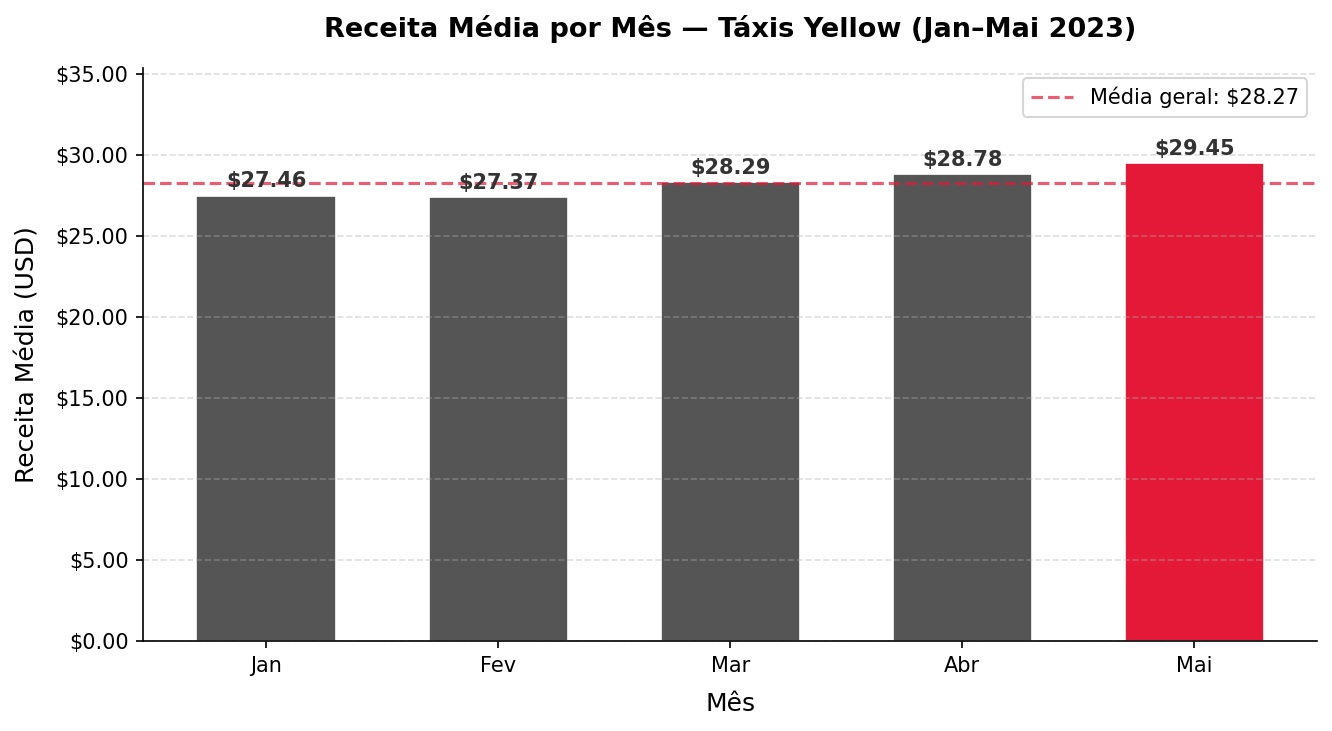

In [0]:
# Aqui lemos direto da Gold — a receita média por mês já está pré-calculada,
# sem precisar refazer o filtro e a agregação da Silver
df_q1 = spark.table("vw_gold_monthly_revenue")
df_q1.show()

# Convertemos para pandas pois o matplotlib trabalha com estruturas locais,
# não com DataFrames distribuídos do Spark
pdf_q1 = df_q1.toPandas()
month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai']
pdf_q1['month_label'] = [month_labels[m-1] for m in pdf_q1['pickup_month']]
# Garantimos ordem cronológica no eixo X independente da ordem retornada pela view
pdf_q1 = pdf_q1.sort_values('pickup_month').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

# Todas as barras começam cinza — só o mês de maior receita recebe destaque em vermelho
bar_colors = ['#555555'] * len(pdf_q1)
max_idx = pdf_q1['avg_total_amount'].idxmax()
bar_colors[max_idx] = '#E31937'

bars = ax.bar(pdf_q1['month_label'], pdf_q1['avg_total_amount'],
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6)

# A linha tracejada mostra a média geral, facilitando comparar cada mês contra o período
mean_val = pdf_q1['avg_total_amount'].mean()
ax.axhline(mean_val, color='#E31937', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Média geral: ${mean_val:.2f}')

# Rótulos sobre cada barra para leitura direta do valor sem depender do eixo Y
for bar, val in zip(bars, pdf_q1['avg_total_amount']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_xlabel('Mês', fontsize=12, labelpad=8)
ax.set_ylabel('Receita Média (USD)', fontsize=12, labelpad=8)
ax.set_title('Receita Média por Mês — Táxis Yellow (Jan–Mai 2023)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
# O teto de 120% do valor máximo evita que os rótulos colidam com a borda do gráfico
ax.set_ylim(0, pdf_q1['avg_total_amount'].max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Renderizamos em buffer de memória para exibir inline no Databricks —
# evita dependência de path e o problema do backend Agg que engolia o plt.show()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)


### 📊 Interpretação

A receita média apresenta uma queda pontual em fevereiro ($27,34 — mês mais curto do ano) e cresce consistentemente de março até maio ($29,46 — pico do período).
A variação total de apenas 7,7% entre os extremos é coerente com um mercado de tarifas reguladas pela NYC TLC,
onde oscilações refletem distância média das corridas, não ajuste de preço. Uma análise da distância média
por mês confirmaria essa hipótese.

## Pergunta 2
**Qual a média do `passenger_count` por hora do dia para as viagens que aconteceram em Maio (Para TODOS os Táxis)?**

+-----------+-------------------+-----------+
|pickup_hour|avg_passenger_count|total_trips|
+-----------+-------------------+-----------+
|          0|               1.43|      89603|
|          1|               1.44|      58245|
|          2|               1.45|      37559|
|          3|               1.45|      24545|
|          4|                1.4|      16067|
|          5|               1.28|      18555|
|          6|               1.26|      46466|
|          7|               1.28|      94115|
|          8|               1.29|     128332|
|          9|               1.31|     144039|
|         10|               1.35|     156610|
|         11|               1.36|     170641|
|         12|               1.37|     183822|
|         13|               1.38|     187747|
|         14|               1.39|     204542|
|         15|                1.4|     209183|
|         16|                1.4|     209684|
|         17|               1.39|     228796|
|         18|               1.38| 

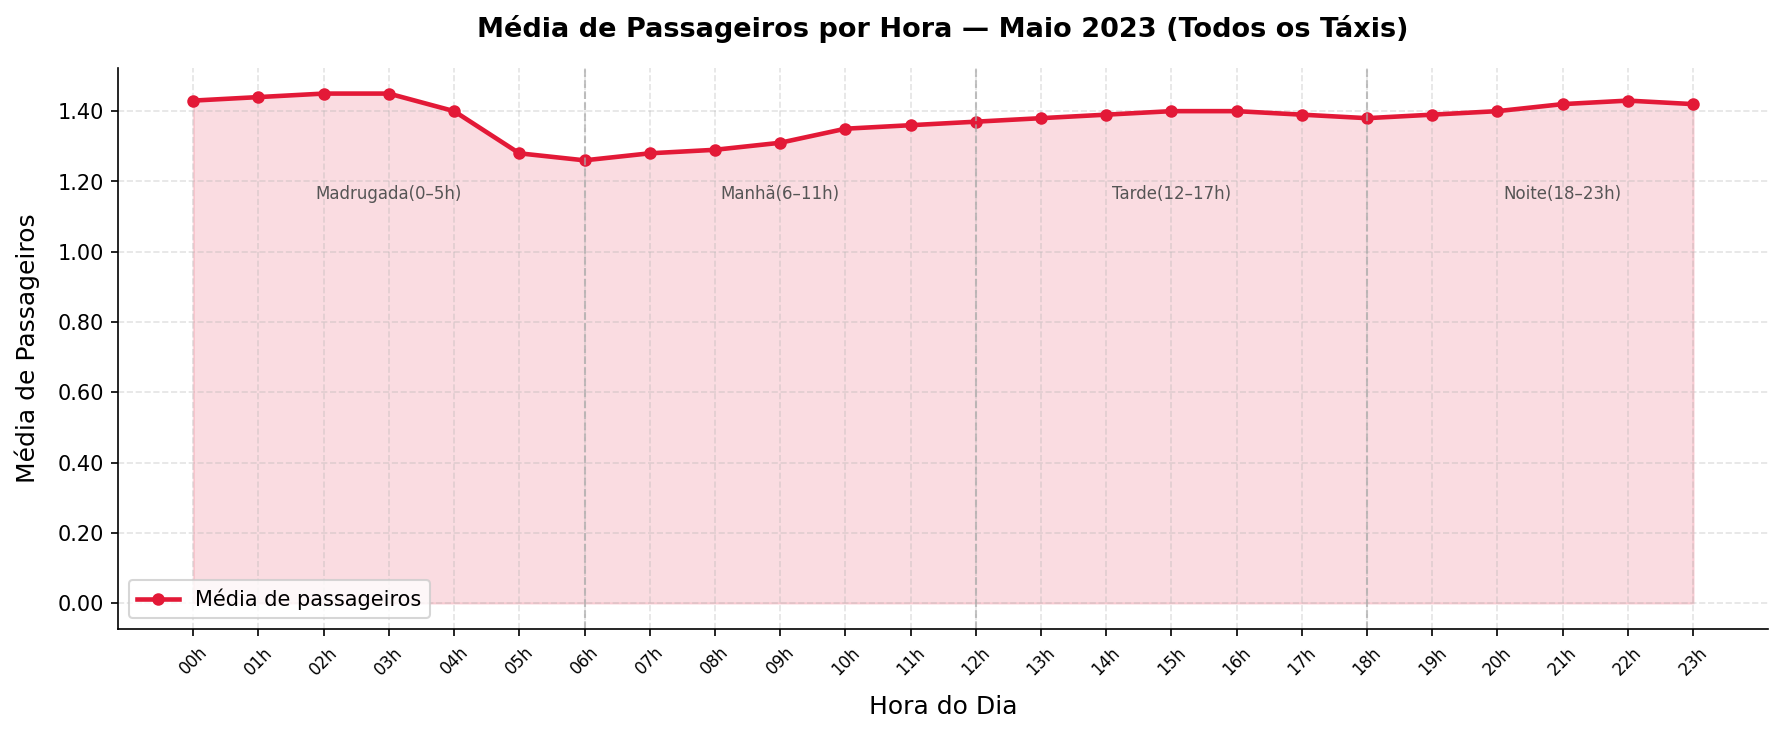

In [0]:
# Aqui lemos direto da Gold — os dados já chegam filtrados e agregados por hora,
# sem precisar refazer o processamento da Silver
df_q2 = spark.table("vw_gold_hourly_passengers")
df_q2.show(24)

# Ordenamos por hora para garantir que o eixo X fique sequencial no gráfico
pdf_q2 = df_q2.toPandas().sort_values("pickup_hour").reset_index(drop=True)

fig2, ax2 = plt.subplots(figsize=(12, 5))

# A área sombreada ajuda a perceber visualmente os picos e vales ao longo do dia
ax2.fill_between(pdf_q2['pickup_hour'], pdf_q2['avg_passenger_count'],
                 alpha=0.15, color='#E31937')
ax2.plot(pdf_q2['pickup_hour'], pdf_q2['avg_passenger_count'],
         color='#E31937', linewidth=2.2, marker='o', markersize=5,
         label='Média de passageiros')

# Dividimos o dia em 4 períodos para facilitar a leitura dos padrões de demanda
periods = [
    (0, 6, 'Madrugada(0–5h)'),
    (6, 12, 'Manhã(6–11h)'),
    (12, 18, 'Tarde(12–17h)'),
    (18, 24, 'Noite(18–23h)')
]
y_min = pdf_q2['avg_passenger_count'].min()
for start, end, label in periods:
    if start > 0:
        ax2.axvline(start, color='#AAAAAA', linestyle='--', linewidth=1, alpha=0.7)
    ax2.text((start + end) / 2, y_min - 0.07, label,
             ha='center', va='top', fontsize=8, color='#555555')

ax2.set_xlabel('Hora do Dia', fontsize=12, labelpad=8)
ax2.set_ylabel('Média de Passageiros', fontsize=12, labelpad=8)
ax2.set_title('Média de Passageiros por Hora — Maio 2023 (Todos os Táxis)',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(range(24))
# Formato 00h–23h deixa o eixo X mais legível que números inteiros
ax2.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=8, rotation=45)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax2.grid(linestyle='--', alpha=0.35)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(fontsize=10)
plt.tight_layout()

# Renderizamos em buffer de memória para exibir inline no Databricks —
# evita dependência de path e o problema do backend Agg que engolia o plt.show()
buf = io.BytesIO()
fig2.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig2)


### 📊 Interpretação

A média de passageiros permanece em uma faixa estreita ao longo do dia (1,26–1,45), indicando que
corridas individuais dominam em todos os períodos. O pico ocorre paradoxalmente na madrugada (2h–3h: 1,45),
quando o volume é baixo (≈40K corridas/hora) mas as corridas tendem a ser em grupo. O vale se dá às 6h (1,26), horário de commute individual
de trabalhadores. Cruzar esse indicador com `total_amount` por hora revelaria se as corridas de madrugada,
apesar de menores em volume, compensam em receita média.
